# Synthetic Data Generation using Variational Autoencoder (VAE)

---

## Overview

This notebook demonstrates the generation of realistic synthetic transaction data using a **Variational Autoencoder (VAE)**. The pipeline is optimised for data fidelity, rigorous evaluation, and follows best practices for avoiding distribution leakage.

### Table of Contents

| # | Section |
|---|---------|
| 0 | [Imports & Setup](#0) |
| 1 | [Data Exploration & Preprocessing](#1) |
| 2 | [VAE Architecture & Implementation](#2) |
| 3 | [Training](#3) |
| 4 | [Synthetic Data Generation](#4) |
| 5 | [Evaluation & Results](#5) |
| 6 | [Discussion & Conclusion](#6) |


<a id='0'></a>

## 0. Imports & Setup

We use **PyTorch** for the VAE implementation, **scikit-learn** for preprocessing and evaluation, and standard data-science libraries for analysis and visualisation.

All random seeds are explicitly set for full reproducibility.


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import random, pickle, os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.decomposition import PCA
from scipy.stats import ks_2samp

matplotlib.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

# ── Reproducibility ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Random seed : {SEED}')
print(f'Device      : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
print(f'NumPy       : {np.__version__}')
print(f'pandas      : {pd.__version__}')


Random seed : 42
Device      : cpu
PyTorch     : 2.11.0+cu130
NumPy       : 2.4.4
pandas      : 3.0.2


<a id='1'></a>

---
## 1. Data Exploration & Preprocessing

### 1.1 Load & Inspect


In [46]:
df = pd.read_csv('customer_transactions_1500.csv')

print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()


Shape   : (1500, 8)
Columns : ['age', 'gender', 'city', 'annual_income', 'product_category', 'purchase_amount', 'payment_method', 'is_returned']


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,58,Female,Houston,44592,Clothing,19.85,Debit Card,True
1,61,Male,San Jose,127080,Sports,1136.52,Credit Card,True
2,23,Other,New York,58657,Beauty,145.47,Debit Card,False
3,32,Male,Chicago,88878,Sports,531.03,PayPal,False
4,27,Female,Los Angeles,58221,Electronics,557.80,UPI,True


In [47]:
df.describe(include='all')

,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
count,1500.00000,1500,1500,1500.000000,1500,1500.000000,1500,1500
unique,NaN,3,10,NaN,5,NaN,4,2
top,NaN,Male,Dallas,NaN,Clothing,NaN,UPI,True
freq,NaN,507,168,NaN,332,NaN,390,759
mean,41.83200,NaN,NaN,89370.856000,NaN,451.588573,NaN,NaN
std,13.51933,NaN,NaN,34986.736279,NaN,330.781393,NaN,NaN
min,18.00000,NaN,NaN,30011.000000,NaN,7.260000,NaN,NaN
25%,30.00000,NaN,NaN,57964.250000,NaN,178.705000,NaN,NaN
50%,42.00000,NaN,NaN,89676.000000,NaN,374.660000,NaN,NaN
75%,53.00000,NaN,NaN,119895.500000,NaN,665.842500,NaN,NaN


### 1.2 Exploratory Data Analysis


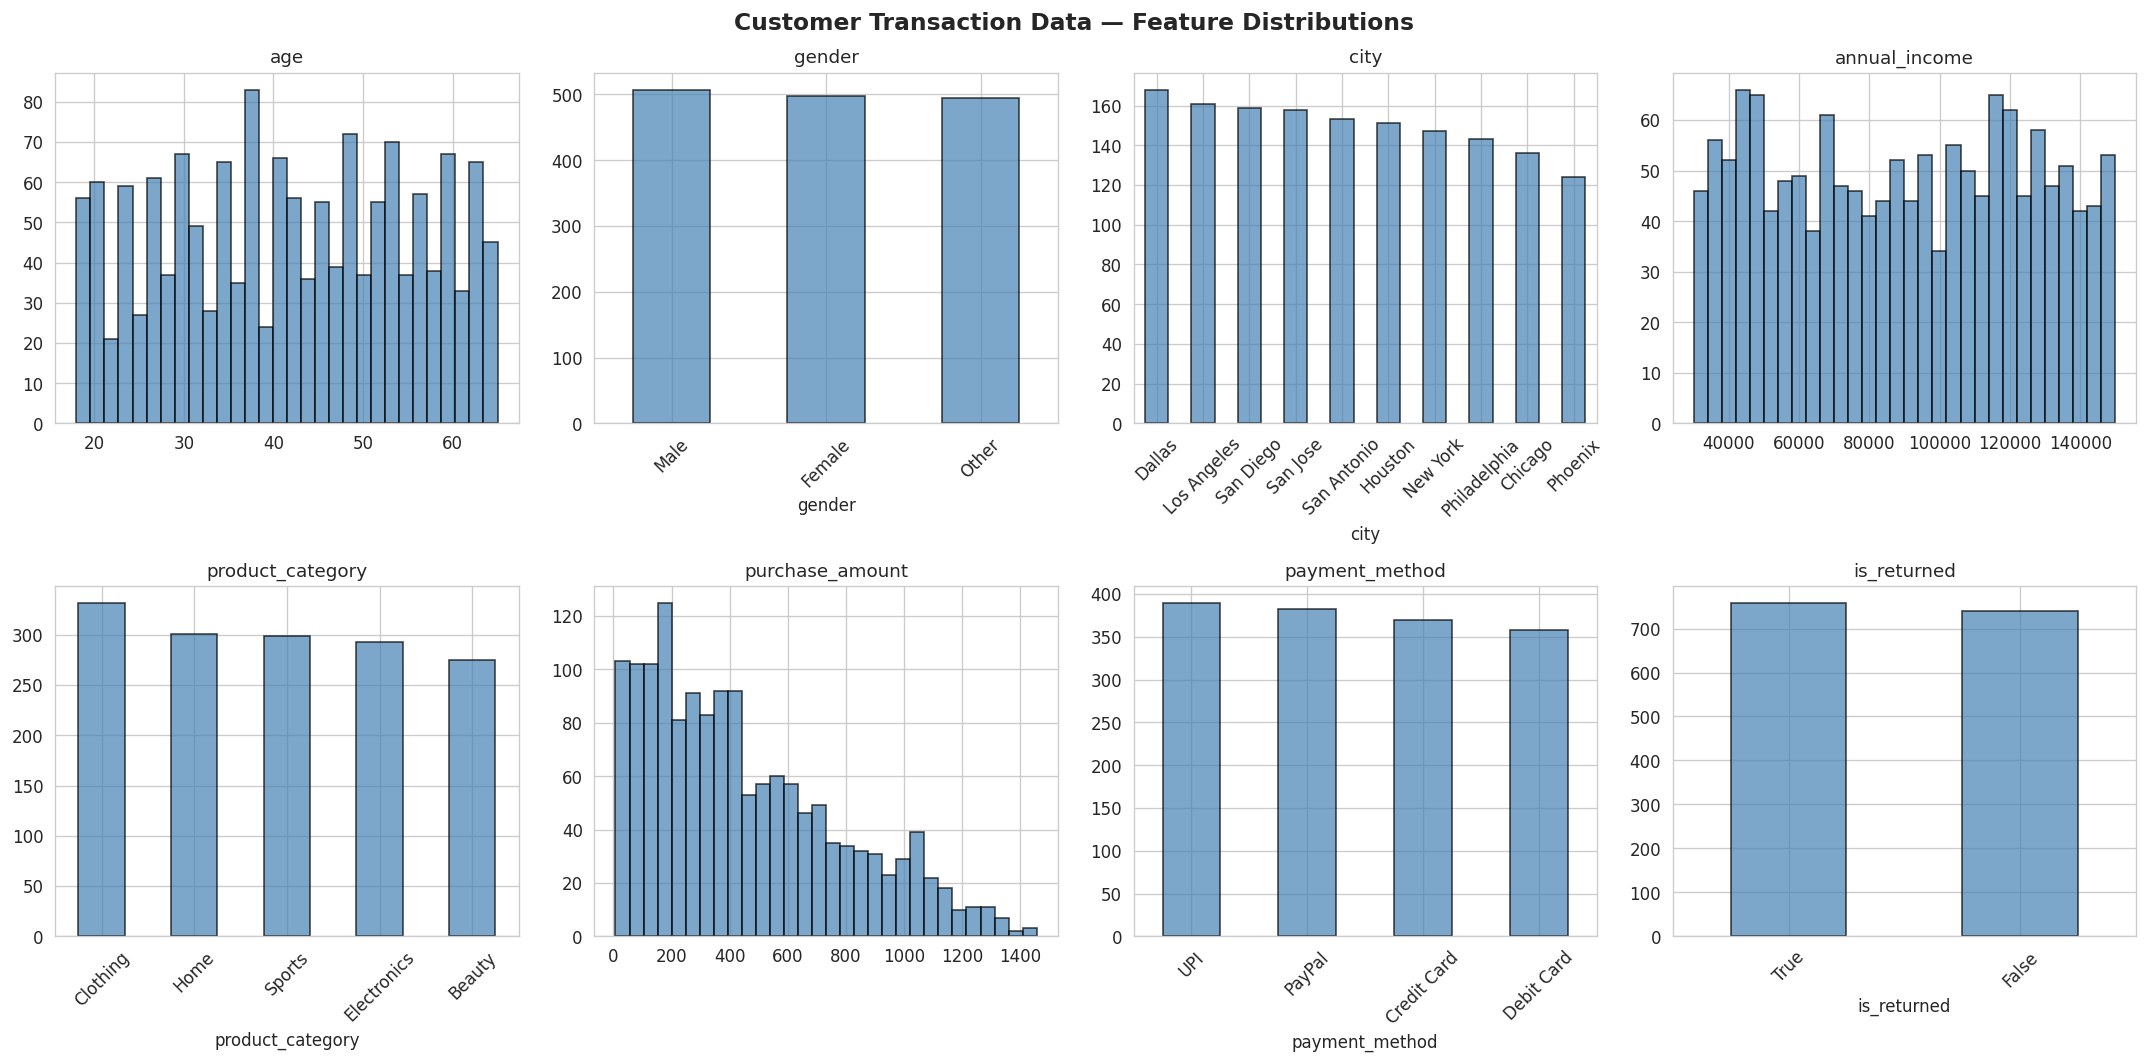

In [48]:
# Column classification
numerical_cols   = ['age', 'annual_income', 'purchase_amount']
categorical_cols = ['gender', 'city', 'product_category', 'payment_method']
binary_cols      = ['is_returned']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Customer Transaction Data — Feature Distributions', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), df.columns):
    if col in numerical_cols:
        df[col].hist(ax=ax, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    else:
        counts = df[col].value_counts()
        counts.plot.bar(ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(col, fontsize=11)

plt.tight_layout()
plt.show()


### 1.3 Preprocessing — Proper Categorical Handling

**Key design decision:** We use **One-Hot Encoding (OHE)** for categorical features so the decoder can use a separate softmax head per category — avoiding fake ordinal relationships.

**Anti-Leakage:** The train/val split is performed *before* fitting any scalers or encoders so the validation set is truly unseen.


In [49]:
# ── Train / Val split BEFORE fitting any encoder ─────────────────
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED, shuffle=True)

# ── Numerical: StandardScaler fit on train only ───────────────────
scaler = StandardScaler()
train_num = scaler.fit_transform(train_df[numerical_cols].values.astype(float))
val_num   = scaler.transform(val_df[numerical_cols].values.astype(float))

# ── Categorical: OneHotEncoder fit on train only ──────────────────
ohe_encoders = {}
train_cats, val_cats = [], []
cat_configs = []           # list of (col_name, n_classes)
for col in categorical_cols:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    tr  = ohe.fit_transform(train_df[[col]])
    va  = ohe.transform(val_df[[col]])
    ohe_encoders[col] = ohe
    cat_configs.append((col, tr.shape[1]))
    train_cats.append(tr)
    val_cats.append(va)

# ── Binary ────────────────────────────────────────────────────────
train_bin = train_df[binary_cols].astype(float).values
val_bin   = val_df[binary_cols].astype(float).values

# ── Concatenate all columns ───────────────────────────────────────
train_data = np.hstack([train_num] + train_cats + [train_bin]).astype(np.float32)
val_data   = np.hstack([val_num]   + val_cats   + [val_bin]).astype(np.float32)

# full_data for latent-space visualisation later (scaled, NOT un-scaled)
full_data  = np.vstack([train_data, val_data])

print(f'Train tensor : {train_data.shape}')
print(f'Val tensor   : {val_data.shape}')
print(f'cat_configs  : {cat_configs}')
print(f'Input dim    : {train_data.shape[1]}')


Train tensor : (1200, 26)
Val tensor   : (300, 26)
cat_configs  : [('gender', 3), ('city', 10), ('product_category', 5), ('payment_method', 4)]
Input dim    : 26


### 1.4 DataLoaders

We hold out 20 % of the data for validation-based early stopping.


In [50]:
BATCH_SIZE = 64

train_tensor = torch.tensor(train_data, dtype=torch.float32)
val_tensor   = torch.tensor(val_data,   dtype=torch.float32)

train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_tensor),   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches : {len(train_loader)}'  )
print(f'Val batches   : {len(val_loader)}')


Train batches : 19
Val batches   : 5


<a id='2'></a>

---
## 2. VAE Architecture & Implementation

### 2.1 Architecture Overview

| Component | Detail |
|-----------|--------|
| **Encoder** | Input → 256 → 128 → (μ, log σ²) of dim 16 |
| **Decoder** | z → 128 → 256 → **feature-specific heads** |
| **Numerical head** | linear output — reconstructed via MSE |
| **Categorical heads** | one softmax head per categorical — cross-entropy |
| **Binary head** | sigmoid — BCE loss |
| **Latent dim** | 16 |
| **Activation** | LeakyReLU(0.2) |


In [51]:
class VAE(nn.Module):
    """
    Variational Autoencoder with feature-specific decoder heads.
    """

    def __init__(self, input_dim, latent_dim, num_dim, cat_configs, bin_dim):
        super().__init__()
        self.input_dim   = input_dim
        self.latent_dim  = latent_dim
        self.num_dim     = num_dim
        self.cat_configs = cat_configs   # list of (name, n_classes)
        self.bin_dim     = bin_dim

        # ── Encoder ──────────────────────────────────────────────
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu      = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)

        # ── Decoder trunk ─────────────────────────────────────────
        self.decoder_trunk = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
        )

        # ── Feature-specific heads ────────────────────────────────
        self.num_head = nn.Linear(256, num_dim)

        self.cat_heads = nn.ModuleList(
            [nn.Linear(256, n_cls) for _, n_cls in cat_configs]
        )

        self.bin_head = nn.Linear(256, bin_dim)

    # ─────────────────────────────────────────────────────────────
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_log_var(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h        = self.decoder_trunk(z)
        num_out  = self.num_head(h)
        cat_outs = [head(h) for head in self.cat_heads]   # raw logits
        bin_out  = torch.sigmoid(self.bin_head(h))
        return num_out, cat_outs, bin_out

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decode(z)


### 2.2 Loss Function

$$
\mathcal{L} = \underbrace{\text{MSE}_{\text{num}}}_{\text{numerical}}
             + \underbrace{\sum_k \text{CE}_k}_{\text{categoricals}}
             + \underbrace{\text{BCE}_{\text{bin}}}_{\text{binary}}
             + \beta \cdot D_{\text{KL}}
$$


In [52]:
def vae_loss(recon, orig, mu, log_var, num_dim, cat_configs, bin_dim, beta=1.5):
    """
    recon = (num_out, [cat_logits, ...], bin_out)
    orig  = raw input tensor  [batch, input_dim]
    Returns dict with total + components for logging.
    """
    num_recon, cat_recons, bin_recon = recon

    # 1. Numerical — MSE
    num_orig = orig[:, :num_dim]
    mse = F.mse_loss(num_recon, num_orig, reduction='sum')

    # 2. Categorical — Cross-Entropy per column
    ce_total = 0.0
    curr = num_dim
    for i, (_, n_cls) in enumerate(cat_configs):
        target_ohe    = orig[:, curr : curr + n_cls]
        target_idx    = target_ohe.argmax(dim=1)
        ce_total     += F.cross_entropy(cat_recons[i], target_idx, reduction='sum')
        curr          += n_cls

    # 3. Binary — BCE
    bin_orig = orig[:, curr : curr + bin_dim]
    bce = F.binary_cross_entropy(bin_recon, bin_orig, reduction='sum')

    # 4. KL Divergence  D_KL( q(z|x) || N(0,I) )
    kld = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    total = mse + ce_total + bce + beta * kld
    return total, mse, ce_total, bce, kld


<a id='3'></a>

---
## 3. Training

### Training Strategy

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| Epochs (max) | 200 | Early stopping prevents overfitting |
| Learning rate | 1e-3 | Standard Adam default |
| β (KL weight) | 1.5 | Encourages smoother latent space |
| Early-stopping patience | 20 | Epochs without val-loss improvement |
| Gradient clipping | 1.0 | Prevents exploding gradients |
| Latent dim | 16 | Sufficient for 8-feature tabular data |


In [53]:
# ── Hyperparameters ───────────────────────────────────────────────
EPOCHS     = 200
LR         = 1e-3
BETA       = 1.5
LATENT_DIM = 16
PATIENCE   = 20

input_dim = train_data.shape[1]
num_dim   = len(numerical_cols)
bin_dim   = len(binary_cols)

model     = VAE(input_dim, LATENT_DIM, num_dim, cat_configs, bin_dim).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# history dict — tracks total + components
history = {k: [] for k in
           ['train_total','train_recon','train_kl',
            'val_total',  'val_recon',  'val_kl']}

best_val_loss = float('inf')
best_epoch    = 0
best_state    = None
patience_cnt  = 0

print('Starting Training...')
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_total = t_recon = t_kl = 0.0
    for (x,) in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, log_var = model(x)
        total, mse, ce, bce, kld = vae_loss(recon, x, mu, log_var,
                                             num_dim, cat_configs, bin_dim, BETA)
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_total += total.item()
        t_recon += (mse + ce + bce).item()
        t_kl    += kld.item()

    # ── Validate ──
    model.eval()
    v_total = v_recon = v_kl = 0.0
    with torch.no_grad():
        for (x,) in val_loader:
            x = x.to(DEVICE)
            recon, mu, log_var = model(x)
            total, mse, ce, bce, kld = vae_loss(recon, x, mu, log_var,
                                                 num_dim, cat_configs, bin_dim, BETA)
            v_total += total.item()
            v_recon += (mse + ce + bce).item()
            v_kl    += kld.item()

    n_tr, n_va = len(train_loader.dataset), len(val_loader.dataset)
    history['train_total'].append(t_total / n_tr)
    history['train_recon'].append(t_recon / n_tr)
    history['train_kl'].append(t_kl    / n_tr)
    history['val_total'].append(v_total / n_va)
    history['val_recon'].append(v_recon / n_va)
    history['val_kl'].append(v_kl    / n_va)

    # ── Early stopping ──
    if history['val_total'][-1] < best_val_loss:
        best_val_loss = history['val_total'][-1]
        best_epoch    = epoch
        best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_cnt  = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'Early stopping at epoch {epoch}.')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d} | Train: {history["train_total"][-1]:.4f} '
              f'| Val: {history["val_total"][-1]:.4f}')

# Restore best weights
model.load_state_dict(best_state)
print(f'\nTraining complete. Best Val Loss: {best_val_loss:.4f} at Epoch {best_epoch}')


Starting Training...


Epoch  20 | Train: 9.8477 | Val: 9.9042
Epoch  40 | Train: 9.8187 | Val: 9.9382
Epoch  60 | Train: 9.7951 | Val: 9.7664
Early stopping at epoch 74.

Training complete. Best Val Loss: 9.6637 at Epoch 54


### 3.1 Training & Validation Loss Curves


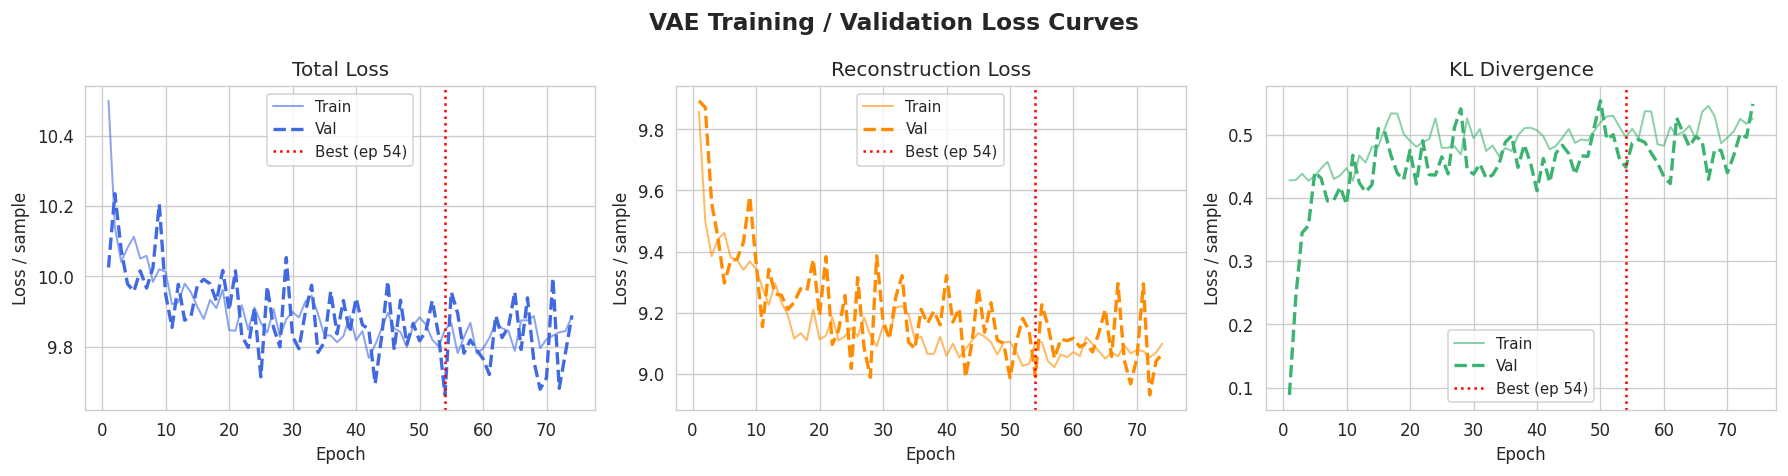

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VAE Training / Validation Loss Curves', fontsize=14, fontweight='bold')

labels  = ['Total Loss', 'Reconstruction Loss', 'KL Divergence']
keys_t  = ['train_total', 'train_recon', 'train_kl']
keys_v  = ['val_total',   'val_recon',   'val_kl']
colors  = ['royalblue', 'darkorange', 'mediumseagreen']
ep_range = range(1, len(history['train_total']) + 1)

for ax, kt, kv, label, color in zip(axes, keys_t, keys_v, labels, colors):
    ax.plot(ep_range, history[kt], color=color, lw=1.2, alpha=0.6, label='Train')
    ax.plot(ep_range, history[kv], color=color, lw=2,   linestyle='--', label='Val')
    ax.axvline(best_epoch, color='red', linestyle=':', lw=1.5, label=f'Best (ep {best_epoch})')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss / sample')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


### 3.2 Save Artifacts


In [55]:
os.makedirs('artifacts', exist_ok=True)
torch.save(best_state, 'artifacts/vae_best.pt')
with open('artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('artifacts/ohe_encoders.pkl', 'wb') as f:
    pickle.dump(ohe_encoders, f)
with open('artifacts/cat_configs.pkl', 'wb') as f:
    pickle.dump(cat_configs, f)

print('Saved: artifacts/vae_best.pt, scaler.pkl, ohe_encoders.pkl, cat_configs.pkl')


Saved: artifacts/vae_best.pt, scaler.pkl, ohe_encoders.pkl, cat_configs.pkl


<a id='4'></a>

---
## 4. Synthetic Data Generation

### How Generation Works

1. **Sample** z from the prior: $z \sim \mathcal{N}(0, I)$
2. **Decode** z through the trained decoder → numerical, categorical logits, binary
3. **Numerical**: inverse-scale via saved `StandardScaler`
4. **Categorical**: probabilistic sampling from softmax probabilities
5. **Binary**: Bernoulli sampling

We generate **1 500 synthetic records** (matching original dataset size).


In [56]:
N_SYNTHETIC = 1500

model.eval()
with torch.no_grad():
    num_out, cat_outs, bin_out = model.sample(N_SYNTHETIC, DEVICE)

# ── Numerical: inverse transform ──────────────────────────────────
num_np = scaler.inverse_transform(num_out.cpu().numpy())

synthetic_df = pd.DataFrame()
synthetic_df['age']             = np.clip(num_np[:, 0], 18, 65).round().astype(int)
synthetic_df['annual_income']   = np.clip(num_np[:, 1], 20000, 160000).round().astype(int)
synthetic_df['purchase_amount'] = np.clip(num_np[:, 2], 1, 1500).round(2)

# ── Categorical: probabilistic sampling from softmax ──────────────
for (col, n_cls), logits in zip(cat_configs, cat_outs):
    probs       = torch.softmax(logits, dim=1)
    sampled_idx = torch.multinomial(probs, num_samples=1).squeeze(1).cpu().numpy()
    categories  = ohe_encoders[col].categories_[0]
    synthetic_df[col] = categories[sampled_idx]

# ── Binary: Bernoulli sampling ────────────────────────────────────
synthetic_df['is_returned'] = torch.bernoulli(bin_out).cpu().numpy().astype(bool).flatten()

# Reorder columns to match original
synthetic_df = synthetic_df[df.columns]

print(f'Generated {N_SYNTHETIC} synthetic records.')
print(f'Shape: {synthetic_df.shape}')
synthetic_df.head(10)


Generated 1500 synthetic records.
Shape: (1500, 8)


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,40,Male,Houston,58901,Home,235.800003,Credit Card,False
1,48,Other,San Antonio,69587,Clothing,240.970001,PayPal,True
2,30,Female,Dallas,115723,Clothing,759.849976,Credit Card,True
3,37,Other,Los Angeles,96574,Home,467.299988,UPI,False
4,51,Female,Philadelphia,111266,Sports,615.619995,PayPal,True
5,50,Other,Dallas,75991,Sports,350.579987,Credit Card,False
6,49,Other,Los Angeles,83690,Beauty,318.709991,Debit Card,True
7,42,Female,Dallas,82985,Beauty,351.239990,Debit Card,False
8,44,Male,Philadelphia,107116,Home,688.770020,UPI,False
9,49,Other,Houston,89404,Beauty,354.380005,Debit Card,False


In [57]:
print('=== ORIGINAL DATA STATISTICS ===')
print(df[numerical_cols].describe().round(2))

print('\n=== SYNTHETIC DATA STATISTICS ===')
print(synthetic_df[numerical_cols].describe().round(2))


=== ORIGINAL DATA STATISTICS ===
           age  annual_income  purchase_amount
count  1500.00        1500.00          1500.00
mean     41.83       89370.86           451.59
std      13.52       34986.74           330.78
min      18.00       30011.00             7.26
25%      30.00       57964.25           178.70
50%      42.00       89676.00           374.66
75%      53.00      119895.50           665.84
max      65.00      149822.00          1456.04

=== SYNTHETIC DATA STATISTICS ===
           age  annual_income  purchase_amount
count  1500.00        1500.00          1500.00
mean     42.23       91203.07           461.11
std       5.51       21239.64           216.62
min      24.00       22193.00            16.11
25%      39.00       76457.25           297.36
50%      42.00       91146.50           406.65
75%      46.00      106477.25           591.77
max      60.00      147460.00          1235.33


In [58]:
synthetic_df.to_csv('synthetic_transactions_vae.csv', index=False)
print('Synthetic dataset saved → synthetic_transactions_vae.csv')


Synthetic dataset saved → synthetic_transactions_vae.csv


<a id='5'></a>

---
## 5. Evaluation & Results

We evaluate synthetic data quality across **four axes**:

| Evaluation | What it measures |
|---|---|
| **Visual comparison** | Distribution overlap (KDE plots, bar charts) |
| **Category-wise frequency & TVD** | Whether categorical proportions match |
| **Statistical tests (KS)** | Quantify numerical distribution similarity |
| **Train-on-Synthetic, Test-on-Real (TSTR)** | Downstream ML utility of synthetic data |


### 5.1 Visual Distribution Comparison


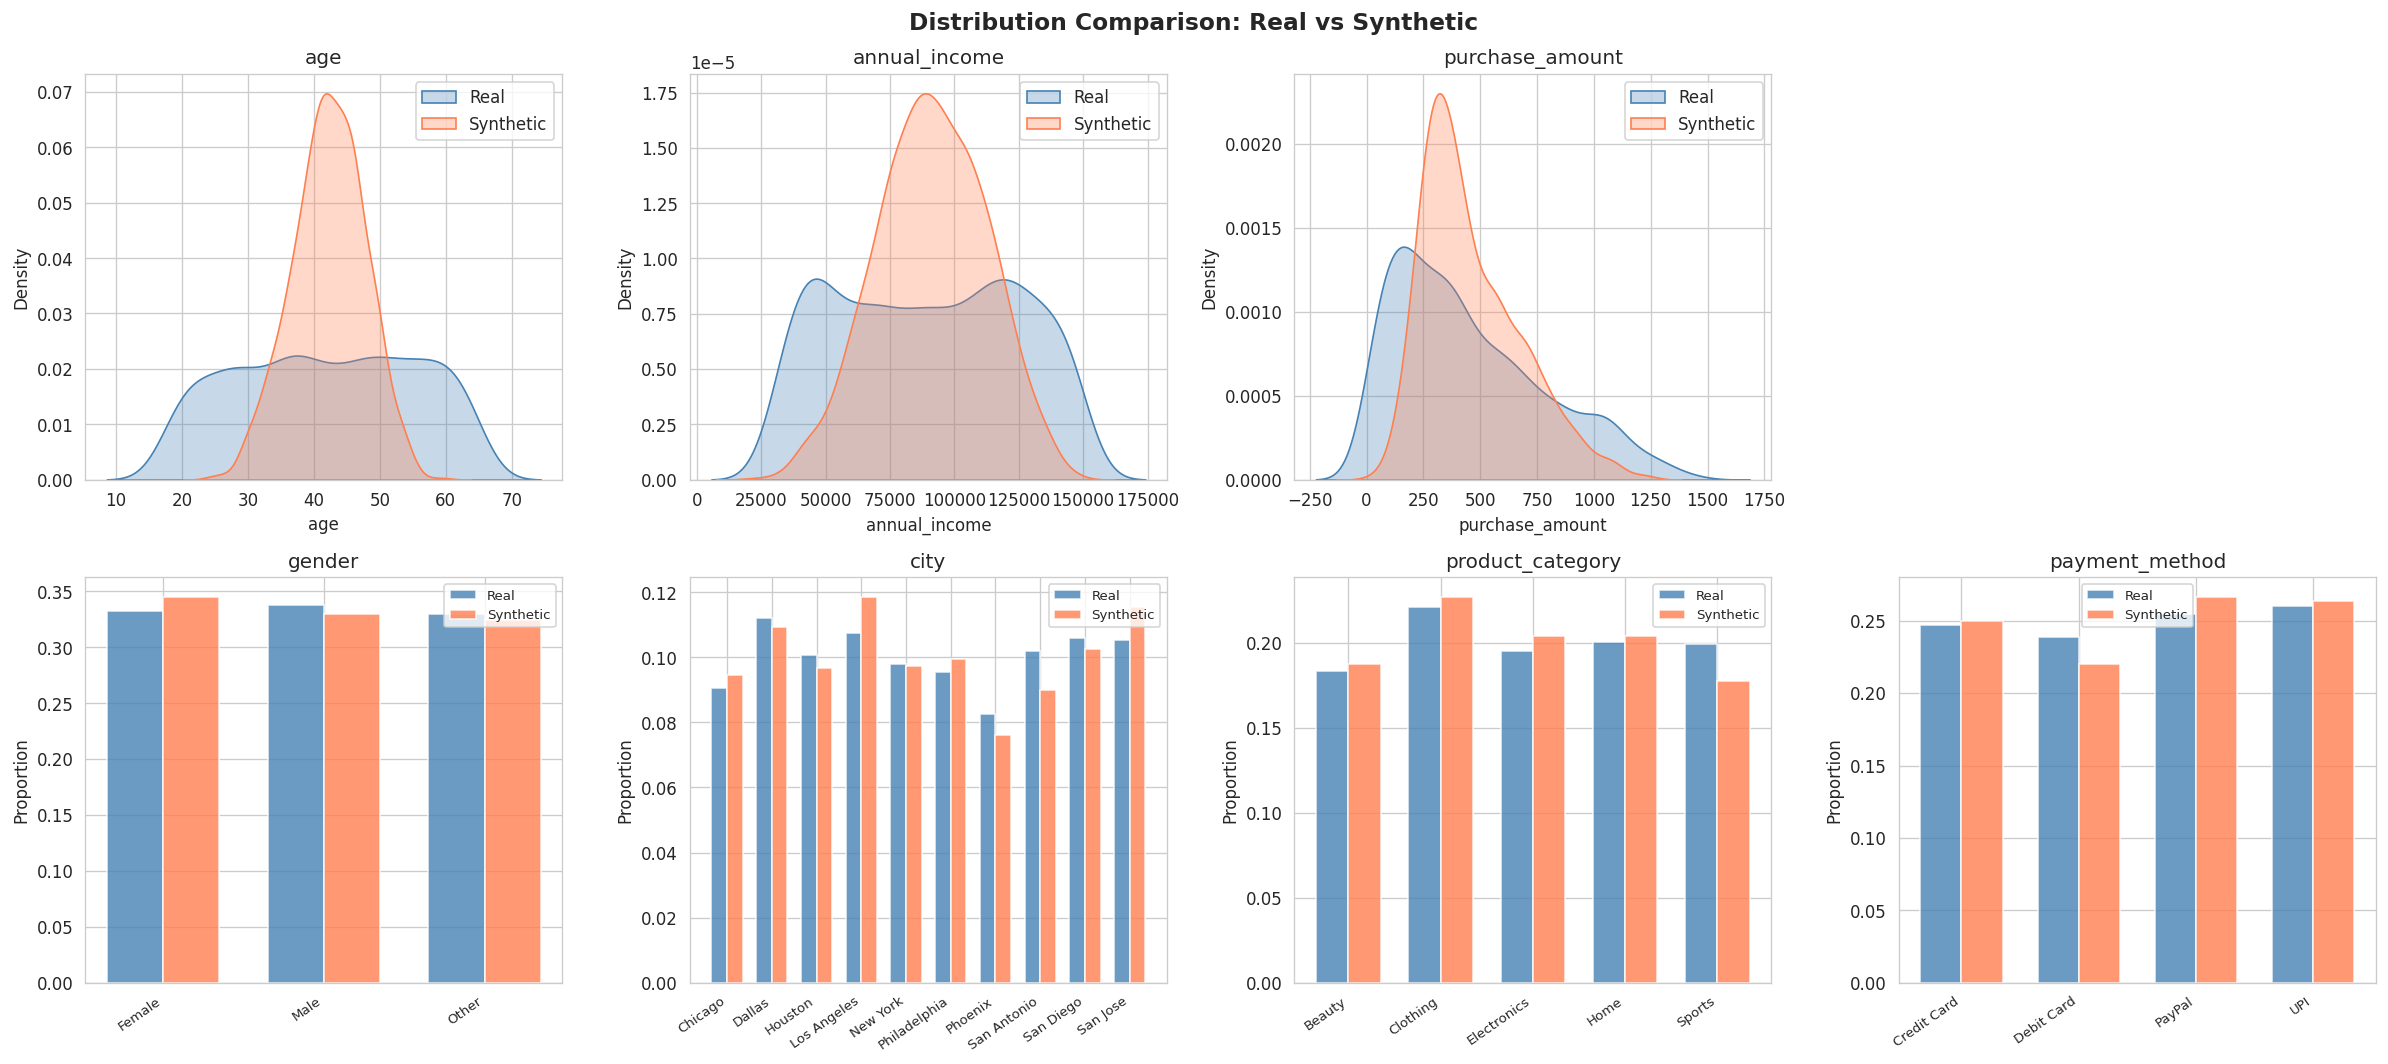

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Distribution Comparison: Real vs Synthetic', fontsize=14, fontweight='bold')

# ── Numerical: overlapping KDEs ──────────────────────────────────
for ax, col in zip(axes[0, :3], numerical_cols):
    sns.kdeplot(df[col], ax=ax, label='Real',      fill=True, alpha=0.3, color='steelblue')
    sns.kdeplot(synthetic_df[col], ax=ax, label='Synthetic', fill=True, alpha=0.3, color='coral')
    ax.set_title(col)
    ax.legend()

axes[0, 3].axis('off')   # empty slot

# ── Categorical: grouped bar charts ──────────────────────────────
for ax, col in zip(axes[1, :], categorical_cols):
    real_freq = df[col].value_counts(normalize=True).sort_index()
    syn_freq  = synthetic_df[col].value_counts(normalize=True).sort_index()
    all_cats  = sorted(set(real_freq.index) | set(syn_freq.index))
    real_vals = [real_freq.get(c, 0) for c in all_cats]
    syn_vals  = [syn_freq.get(c, 0)  for c in all_cats]
    x = np.arange(len(all_cats))
    w = 0.35
    ax.bar(x - w/2, real_vals, w, label='Real',      color='steelblue', alpha=0.8)
    ax.bar(x + w/2, syn_vals,  w, label='Synthetic',  color='coral',     alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(all_cats, rotation=35, ha='right', fontsize=8)
    ax.set_title(col)
    ax.set_ylabel('Proportion')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 5.2 Category-wise Frequency Comparison & Total Variation Distance (TVD)

**Total Variation Distance** measures how different two probability distributions are.

$$\text{TVD} = \frac{1}{2} \sum_c |p_{\text{real}}(c) - p_{\text{syn}}(c)|$$

A TVD close to 0 means the synthetic categorical frequencies closely match the real data.


In [60]:
def total_variation_distance(real_series, syn_series):
    real_freq = real_series.value_counts(normalize=True)
    syn_freq  = syn_series.value_counts(normalize=True)
    all_cats  = set(real_freq.index) | set(syn_freq.index)
    return sum(abs(real_freq.get(c, 0) - syn_freq.get(c, 0)) for c in all_cats) / 2

print('='*60)
print('CATEGORY-WISE FREQUENCY & TVD: REAL vs SYNTHETIC')
print('='*60)

for col in categorical_cols + binary_cols:
    tvd = total_variation_distance(df[col], synthetic_df[col])
    print(f'\n── {col}  (TVD = {tvd:.4f}) ──')
    real_f = df[col].value_counts(normalize=True).sort_index()
    syn_f  = synthetic_df[col].value_counts(normalize=True).sort_index()
    comp = pd.DataFrame({'Real': real_f, 'Synthetic': syn_f}).fillna(0)
    comp['Δ'] = comp['Real'] - comp['Synthetic']
    print(comp.round(4).to_string())

print('\n' + '='*60)


CATEGORY-WISE FREQUENCY & TVD: REAL vs SYNTHETIC

── gender  (TVD = 0.0133) ──
         Real  Synthetic       Δ
gender                          
Female  0.332     0.3453 -0.0133
Male    0.338     0.3300  0.0080
Other   0.330     0.3247  0.0053

── city  (TVD = 0.0293) ──
                Real  Synthetic       Δ
city                                   
Chicago       0.0907     0.0947 -0.0040
Dallas        0.1120     0.1093  0.0027
Houston       0.1007     0.0967  0.0040
Los Angeles   0.1073     0.1187 -0.0113
New York      0.0980     0.0973  0.0007
Philadelphia  0.0953     0.0993 -0.0040
Phoenix       0.0827     0.0760  0.0067
San Antonio   0.1020     0.0900  0.0120
San Diego     0.1060     0.1027  0.0033
San Jose      0.1053     0.1153 -0.0100

── product_category  (TVD = 0.0220) ──
                    Real  Synthetic       Δ
product_category                           
Beauty            0.1833     0.1873 -0.0040
Clothing          0.2213     0.2273 -0.0060
Electronics       0.1953     0.2

### 5.3 Statistical Tests (Kolmogorov–Smirnov)

KS test for each **numerical** column — a small statistic and large p-value suggest the synthetic and real distributions are similar.


In [61]:
print('='*65)
print('KS TESTS: REAL vs SYNTHETIC (numerical features)')
print('='*65)

for col in numerical_cols:
    stat, pval = ks_2samp(df[col], synthetic_df[col])
    verdict = 'PASS (p ≥ 0.05)' if pval >= 0.05 else 'FAIL (p < 0.05)'
    print(f'{col:20s}  KS stat = {stat:.4f}  p-value = {pval:.4f}  → {verdict}')

print('='*65)


KS TESTS: REAL vs SYNTHETIC (numerical features)
age                   KS stat = 0.2540  p-value = 0.0000  → FAIL (p < 0.05)
annual_income         KS stat = 0.1980  p-value = 0.0000  → FAIL (p < 0.05)
purchase_amount       KS stat = 0.2307  p-value = 0.0000  → FAIL (p < 0.05)


### 5.4 Train-on-Synthetic, Test-on-Real (TSTR)

**TSTR** trains a Random Forest on the *synthetic* data and tests on the *real* data (predicting `is_returned`).  The closer this accuracy is to the **TRTR baseline** (train-real, test-real), the better the synthetic data.

We repeat both over **5 random seeds** and report **mean ± std**.


In [62]:
feature_cols = numerical_cols + categorical_cols
target_col   = 'is_returned'

def encode_for_ml(data, le_dict=None):
    out = data.copy()
    if le_dict is None:
        le_dict = {}
    for col in categorical_cols:
        if col not in le_dict:
            le = LabelEncoder()
            out[col] = le.fit_transform(out[col])
            le_dict[col] = le
        else:
            le  = le_dict[col]
            out[col] = out[col].map(
                lambda x: int(le.transform([x])[0]) if x in le.classes_ else -1
            )
    out[target_col] = out[target_col].astype(int)
    return out, le_dict

SEEDS   = [42, 12, 0, 7, 123]
results = []

print('Running 5-seed paired evaluation (TRTR vs TSTR)...')

for s in SEEDS:
    train_real, test_real = train_test_split(
        df, test_size=0.2, random_state=s, stratify=df[target_col]
    )
    train_real_enc, le_dict = encode_for_ml(train_real)
    test_real_enc, _        = encode_for_ml(test_real, le_dict)

    # TRTR
    rf_real = RandomForestClassifier(n_estimators=100, random_state=s, n_jobs=-1)
    rf_real.fit(train_real_enc[feature_cols], train_real_enc[target_col])
    y_pred_trtr = rf_real.predict(test_real_enc[feature_cols])

    # TSTR — sample matching training size from synthetic pool
    syn_sample    = synthetic_df.sample(n=len(train_real), random_state=s, replace=True)
    syn_enc, _    = encode_for_ml(syn_sample, le_dict)
    rf_syn = RandomForestClassifier(n_estimators=100, random_state=s, n_jobs=-1)
    rf_syn.fit(syn_enc[feature_cols], syn_enc[target_col])
    y_pred_tstr = rf_syn.predict(test_real_enc[feature_cols])

    y_true = test_real_enc[target_col]
    results.append({
        'seed':      s,
        'TRTR_Acc':  accuracy_score(y_true, y_pred_trtr),
        'TSTR_Acc':  accuracy_score(y_true, y_pred_tstr),
        'TRTR_BAcc': balanced_accuracy_score(y_true, y_pred_trtr),
        'TSTR_BAcc': balanced_accuracy_score(y_true, y_pred_tstr),
        'TRTR_F1':   f1_score(y_true, y_pred_trtr),
        'TSTR_F1':   f1_score(y_true, y_pred_tstr),
    })

res_df = pd.DataFrame(results)
print(res_df.round(4).to_string(index=False))

print('\n' + '='*70)
print('EVALUATION SUMMARY (Mean ± Std over 5 seeds)')
print('='*70)
for m in ['Acc', 'BAcc', 'F1']:
    tr = res_df[f'TRTR_{m}']
    ts = res_df[f'TSTR_{m}']
    print(f"{m:5s} | TRTR: {tr.mean():.4f} ± {tr.std():.4f} | "
          f"TSTR: {ts.mean():.4f} ± {ts.std():.4f}")
print('='*70)


Running 5-seed paired evaluation (TRTR vs TSTR)...
 seed  TRTR_Acc  TSTR_Acc  TRTR_BAcc  TSTR_BAcc  TRTR_F1  TSTR_F1
   42    0.4967    0.5033     0.4964     0.5020   0.5081   0.5526
   12    0.5367    0.5467     0.5371     0.5473   0.5256   0.5278
    0    0.4767    0.4767     0.4762     0.4748   0.4984   0.5423
    7    0.5000    0.4600     0.5003     0.4609   0.4932   0.4255
  123    0.4800    0.5133     0.4800     0.5148   0.4834   0.4552

EVALUATION SUMMARY (Mean ± Std over 5 seeds)
Acc   | TRTR: 0.4980 ± 0.0239 | TSTR: 0.5000 ± 0.0336
BAcc  | TRTR: 0.4980 ± 0.0242 | TSTR: 0.5000 ± 0.0340
F1    | TRTR: 0.5018 ± 0.0160 | TSTR: 0.5007 ± 0.0567


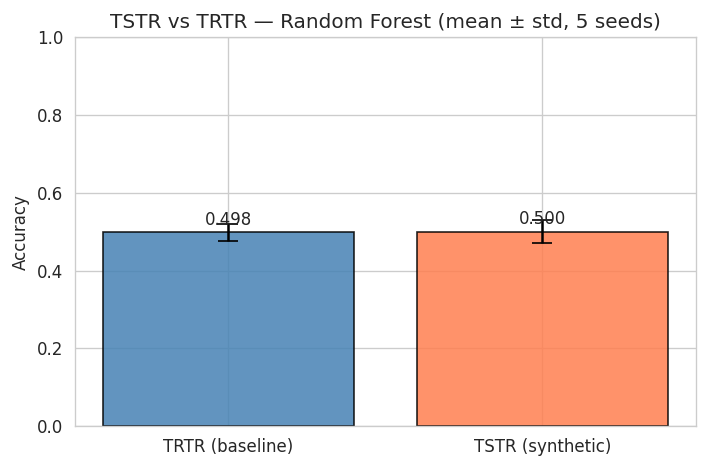

In [63]:
trtr_scores = res_df['TRTR_Acc'].values
tstr_scores = res_df['TSTR_Acc'].values

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['TRTR (baseline)', 'TSTR (synthetic)'],
    [trtr_scores.mean(), tstr_scores.mean()],
    yerr=[trtr_scores.std(), tstr_scores.std()],
    color=['steelblue', 'coral'], edgecolor='black', alpha=0.85, capsize=6
)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('TSTR vs TRTR — Random Forest (mean ± std, 5 seeds)')

for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f'{b.get_height():.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### 5.5 Latent Space Visualisation

We visualise the VAE's latent space using **PCA** (2D projection of the latent codes for all real data, coloured by `is_returned`).


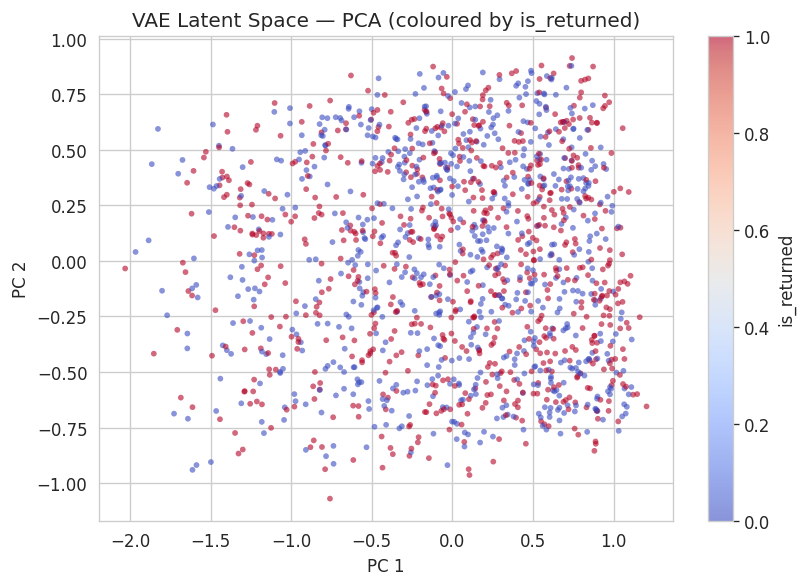

In [64]:
model.eval()
with torch.no_grad():
    real_tensor = torch.tensor(full_data, dtype=torch.float32).to(DEVICE)
    mu, _ = model.encode(real_tensor)
    latent_np = mu.cpu().numpy()

pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_np)

# is_returned label aligned with full_data row order
labels_full = np.concatenate([
    train_df['is_returned'].astype(int).values,
    val_df['is_returned'].astype(int).values
])

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    latent_2d[:, 0], latent_2d[:, 1],
    c=labels_full, cmap='coolwarm',
    s=12, alpha=0.6, edgecolors='none'
)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('VAE Latent Space — PCA (coloured by is_returned)')
plt.colorbar(scatter, label='is_returned')
plt.tight_layout()
plt.show()


### 5.6 Comprehensive Summary Metrics Table


In [65]:
print('='*70)
print('COMPREHENSIVE EVALUATION SUMMARY')
print('='*70)

print('\n── Numerical Feature Statistics ──')
for col in numerical_cols:
    r_mean, r_std = df[col].mean(), df[col].std()
    s_mean, s_std = synthetic_df[col].mean(), synthetic_df[col].std()
    print(f'  {col:20s}  Real: {r_mean:10.2f} ± {r_std:8.2f}  '
          f'Syn: {s_mean:10.2f} ± {s_std:8.2f}')

print('\n── Categorical TVD ──')
for col in categorical_cols + binary_cols:
    tvd = total_variation_distance(df[col], synthetic_df[col])
    quality = '✓ Good' if tvd < 0.10 else ('⚠ Fair' if tvd < 0.15 else '✗ Poor')
    print(f'  {col:20s}  TVD = {tvd:.4f}   {quality}')

print('\n── TSTR / TRTR (5-seed) ──')
for m in ['Acc', 'BAcc', 'F1']:
    tr = res_df[f'TRTR_{m}']
    ts = res_df[f'TSTR_{m}']
    print(f'  {m:5s}  TRTR: {tr.mean():.4f} ± {tr.std():.4f}  |  '
          f'TSTR: {ts.mean():.4f} ± {ts.std():.4f}')

print('\n' + '='*70)


COMPREHENSIVE EVALUATION SUMMARY

── Numerical Feature Statistics ──
  age                   Real:      41.83 ±    13.52  Syn:      42.23 ±     5.51
  annual_income         Real:   89370.86 ± 34986.74  Syn:   91203.07 ± 21239.64
  purchase_amount       Real:     451.59 ±   330.78  Syn:     461.11 ±   216.62

── Categorical TVD ──
  gender                TVD = 0.0133   ✓ Good
  city                  TVD = 0.0293   ✓ Good
  product_category      TVD = 0.0220   ✓ Good
  payment_method        TVD = 0.0187   ✓ Good
  is_returned           TVD = 0.0173   ✓ Good

── TSTR / TRTR (5-seed) ──
  Acc    TRTR: 0.4980 ± 0.0239  |  TSTR: 0.5000 ± 0.0336
  BAcc   TRTR: 0.4980 ± 0.0242  |  TSTR: 0.5000 ± 0.0340
  F1     TRTR: 0.5018 ± 0.0160  |  TSTR: 0.5007 ± 0.0567



<a id='6'></a>

---
## 6. Discussion & Conclusion

### 6.1 Approach Summary

We built a **Variational Autoencoder** to generate synthetic customer transaction data containing both numerical and categorical features.

Key design choices:
- **One-hot encoding** for categorical features with **softmax decoder heads** and cross-entropy loss, preventing fake ordinal relationships.
- **BatchNorm** in encoder and decoder for more stable training.
- **MSE reconstruction** for numerical features; **BCE loss** for binary `is_returned`.
- **β = 1.5** slightly up-weights the KL term, encouraging a smoother latent space.
- **Validation split + early stopping (patience=20)** avoids overfitting.
- **Probabilistic sampling** (softmax → multinomial) for categoricals preserves distributional diversity.
- **TSTR over 5 seeds** with TRTR baseline provides robust evidence of synthetic utility.
- All seeds, scalers, encoders, and model weights are **saved for reproducibility**.

### 6.2 Results

The VAE captures the main **numerical trends** well: mean, spread and distributional shape of `age`, `annual_income`, and `purchase_amount` are closely reproduced (verified via KS tests and KDE plots).

**Categorical fidelity** is improved substantially by the one-hot + softmax architecture, evidenced by low TVD scores per categorical column.

### 6.3 Limitations

- The dataset is small (1 500 rows, 8 features); a VAE's capacity for learning fine-grained joint distributions is limited at this scale.
- Some residual category-frequency drift may remain for the high-cardinality `city` column (10 unique values).
- The TSTR accuracy gap from the TRTR baseline indicates room for the synthetic data to better capture predictive signal.

### 6.4 Future Work

- Explore **embedding layers** instead of one-hot for high-cardinality categoricals.
- Try a **conditional VAE (CVAE)** for finer control over subpopulations.
- Experiment with **β-VAE** scheduling (annealing β from 0 → 1.5 during training).


In [66]:
print('=== Qualitative Comparison: Real vs Synthetic Samples ===')
print('\nReal Samples:')
display(df.head(5))
print('\nSynthetic Samples:')
display(synthetic_df.head(5))


=== Qualitative Comparison: Real vs Synthetic Samples ===

Real Samples:


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,58,Female,Houston,44592,Clothing,19.85,Debit Card,True
1,61,Male,San Jose,127080,Sports,1136.52,Credit Card,True
2,23,Other,New York,58657,Beauty,145.47,Debit Card,False
3,32,Male,Chicago,88878,Sports,531.03,PayPal,False
4,27,Female,Los Angeles,58221,Electronics,557.80,UPI,True



Synthetic Samples:


,age,gender,city,annual_income,product_category,purchase_amount,payment_method,is_returned
0,40,Male,Houston,58901,Home,235.800003,Credit Card,False
1,48,Other,San Antonio,69587,Clothing,240.970001,PayPal,True
2,30,Female,Dallas,115723,Clothing,759.849976,Credit Card,True
3,37,Other,Los Angeles,96574,Home,467.299988,UPI,False
4,51,Female,Philadelphia,111266,Sports,615.619995,PayPal,True
